# Notebook 04 — Multi-Head Attention, then Collapse to One

*Why multiple smaller heads beat one large head — and why we're going to give it up anyway.*

## What we're doing and why

Notebook 03's single head learned **one** attention pattern: one query projection, one key projection, one value projection. The whole model attends one way.

Real language has many things going on at once: subject-verb agreement, local word formation, punctuation matching, topic continuity. A single head has to compromise across all of them.

**Multi-head attention** runs `H` heads in parallel, each with its own small `Q/K/V`, then concatenates their outputs. Each head can specialize on a different attention pattern. Total parameter count stays roughly the same (each head is smaller).

Then — because our hardware target is `1 head, 1 layer` — we'll **deliberately collapse back to 1 head** and measure what we lose. The goal is for you to understand the tradeoff with eyes open.

### What's new in this notebook

1. `MultiHeadAttention` module — parallel heads, concat, output projection.
2. Side-by-side training: 1-head model (from nb03) vs 4-head model with same total dim.
3. Per-head attention visualization — see specialization emerge.
4. Collapse to 1 head, measure the loss hit, accept it as the hardware tax.


## Cell 1 — Setup (same tokenizer + data as nb03)


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

torch.manual_seed(1337)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

text = Path('../data/tinyshakespeare.txt').read_text().lower()
VOCAB_SIZE = 32
top_chars = [c for c, _ in Counter(text).most_common(VOCAB_SIZE - 1)]
itos = ['<unk>'] + top_chars
stoi = {c: i for i, c in enumerate(itos)}
encode = lambda s: [stoi.get(c, 0) for c in s]
decode = lambda ids: ''.join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

BATCH_SIZE = 64
BLOCK_SIZE = 16
EMBED_DIM  = 8
LR         = 3e-3
N_STEPS    = 5000
EVAL_EVERY = 250

def get_batch(split):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(0, len(d) - BLOCK_SIZE - 1, (BATCH_SIZE,))
    x = torch.stack([d[i     : i + BLOCK_SIZE    ] for i in ix])
    y = torch.stack([d[i + 1 : i + BLOCK_SIZE + 1] for i in ix])
    return x.to(device), y.to(device)


device: cuda


## Cell 2 — `Head` (unchanged) and `MultiHeadAttention` (new)

### The shape contract

In single-head:
- `head_size = embed_dim`
- One `Head(embed_dim, head_size)` produces `(B, T, head_size)`.
- That output is fed directly to `lm_head: Linear(head_size, vocab)`.

In multi-head with `H` heads:
- `head_size = embed_dim / H`. (Must divide cleanly. E.g. `embed_dim=8, H=4 → head_size=2`.)
- `H` parallel heads each produce `(B, T, head_size)`.
- Concatenate them along the channel axis → `(B, T, H * head_size) = (B, T, embed_dim)`.
- Pass through a final **output projection** `Linear(embed_dim, embed_dim)`.

### Why the output projection?

Concatenation produces a block-diagonal-ish structure where each chunk of channels came from a different head. The output projection lets the model **mix across heads** — taking a weighted combination of all heads' outputs as the final representation. Without it, heads stay siloed.

### Why heads are *smaller*, not *more*

Parameter cost of `H` heads each of size `head_size = embed_dim / H`:

- Each head's Q/K/V: `3 × embed_dim × head_size = 3 × embed_dim × (embed_dim / H)`.
- All H heads together: `3 × embed_dim²`.

Same as a single head of size `embed_dim`. **Multi-head is a free reorganization** of the same parameter budget into multiple specialists, not an addition of parameters.

(The output projection is extra: `embed_dim²` more. Some implementations skip it or fold it into the next layer; we'll keep it.)


In [3]:
class Head(nn.Module):
    def __init__(self, embed_dim, head_size, block_size):
        super().__init__()
        self.key   = nn.Linear(embed_dim, head_size, bias=False)
        self.query = nn.Linear(embed_dim, head_size, bias=False)
        self.value = nn.Linear(embed_dim, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.head_size = head_size
    def forward(self, x, return_weights=False):
        B, T, _ = x.shape
        k = self.key(x); q = self.query(x); v = self.value(x)
        scores = q @ k.transpose(-2, -1) / (self.head_size ** 0.5)
        scores = scores.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        w = F.softmax(scores, dim=-1)
        out = w @ v
        return (out, w) if return_weights else out

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, block_size):
        super().__init__()
        assert embed_dim % num_heads == 0, 'embed_dim must be divisible by num_heads'
        head_size = embed_dim // num_heads
        self.heads = nn.ModuleList([Head(embed_dim, head_size, block_size) for _ in range(num_heads)])
        self.proj  = nn.Linear(embed_dim, embed_dim)   # output projection — mixes heads

    def forward(self, x, return_weights=False):
        if return_weights:
            outs, ws = zip(*[h(x, return_weights=True) for h in self.heads])
            out = torch.cat(outs, dim=-1)
            return self.proj(out), torch.stack(ws, dim=1)   # weights: (B, H, T, T)
        out = torch.cat([h(x) for h in self.heads], dim=-1)  # (B, T, embed_dim)
        return self.proj(out)


## Cell 3 — The model: same as nb03 but swap `Head` for `MultiHeadAttention`

Identical otherwise. This makes the comparison clean.


In [4]:
class TinyTransformerMH(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, block_size):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed   = nn.Embedding(block_size, embed_dim)
        self.attn        = MultiHeadAttention(embed_dim, num_heads, block_size)
        self.lm_head     = nn.Linear(embed_dim, vocab_size)
        self.block_size  = block_size

    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.token_embed(idx) + self.pos_embed(torch.arange(T, device=idx.device))
        h = self.attn(x)
        logits = self.lm_head(h)
        if targets is None: return logits, None
        loss = F.cross_entropy(logits.view(B*T, -1), targets.view(B*T))
        return logits, loss


## Cell 4 — Train two models side by side: 1 head vs 4 heads

Same `embed_dim=8`. Single-head means `head_size=8`. Four-head means `head_size=2` (four parallel size-2 heads).

Both train for `N_STEPS` on identical batches. We log both loss curves to a single plot for a clean visual comparison.

### What to predict before running

At this scale (embed_dim=8), the *room* for specialization is tight — `head_size=2` is *very* small per head. Don't expect a huge win. Often single-head and multi-head land within ~0.05 nats of each other at this scale. The lesson is the architecture, not the magnitude.


In [5]:
def train_model(model, n_steps=N_STEPS):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    history = []
    for step in range(n_steps + 1):
        if step % EVAL_EVERY == 0:
            model.eval()
            with torch.no_grad():
                losses = {}
                for split in ('train', 'val'):
                    ls = torch.zeros(20)
                    for k in range(20):
                        xb, yb = get_batch(split)
                        _, l = model(xb, yb)
                        ls[k] = l.item()
                    losses[split] = ls.mean().item()
            history.append((step, losses['train'], losses['val']))
            model.train()
        xb, yb = get_batch('train')
        _, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True); loss.backward(); optimizer.step()
    return history

# 1-head and 4-head models, same total embed_dim
torch.manual_seed(1337)
m1 = TinyTransformerMH(VOCAB_SIZE, EMBED_DIM, num_heads=1, block_size=BLOCK_SIZE).to(device)
torch.manual_seed(1337)
m4 = TinyTransformerMH(VOCAB_SIZE, EMBED_DIM, num_heads=4, block_size=BLOCK_SIZE).to(device)

print(f'1-head params: {sum(p.numel() for p in m1.parameters())}')
print(f'4-head params: {sum(p.numel() for p in m4.parameters())}')

print('\ntraining 1-head...')
hist1 = train_model(m1)
print('\ntraining 4-head...')
hist4 = train_model(m4)


1-head params: 936
4-head params: 936

training 1-head...

training 4-head...


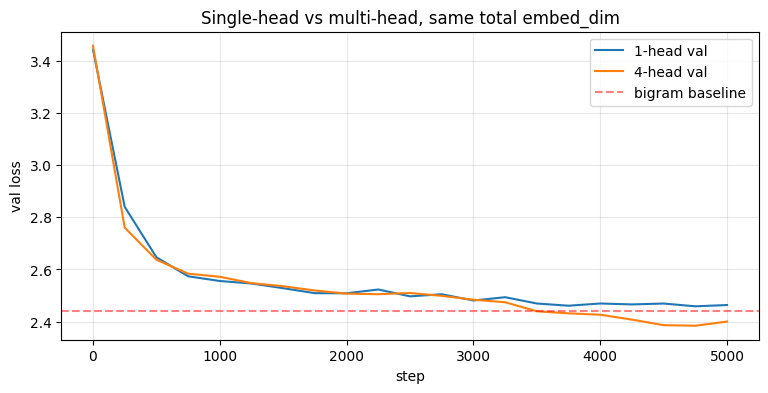

final 1-head val: 2.4634
final 4-head val: 2.4000
gap: +0.0635  (positive = multi-head won)


In [6]:
# Plot comparison
s1, t1, v1 = zip(*hist1)
s4, t4, v4 = zip(*hist4)
plt.figure(figsize=(9, 4))
plt.plot(s1, v1, label='1-head val', color='C0')
plt.plot(s4, v4, label='4-head val', color='C1')
plt.axhline(2.44, color='red', linestyle='--', alpha=0.5, label='bigram baseline')
plt.xlabel('step'); plt.ylabel('val loss')
plt.title('Single-head vs multi-head, same total embed_dim')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print(f'final 1-head val: {v1[-1]:.4f}')
print(f'final 4-head val: {v4[-1]:.4f}')
print(f'gap: {v1[-1] - v4[-1]:+.4f}  (positive = multi-head won)')


## Cell 5 — Visualize per-head attention patterns

Now we look inside the trained 4-head model. Each head should have learned a *different* attention pattern. Common specializations:

- **A "previous token" head**: bright diagonal one-step-left band. Useful for bigram-like predictions.
- **A "start of sequence" head**: bright vertical stripe on column 0. Useful for global context.
- **A "last space" head**: bright vertical stripe on the most recent space character. Useful for word-boundary effects.
- **A "diffuse" head**: nearly uniform. The model couldn't find a useful specialization for this slot.

At our scale you probably won't get *clean* specializations — patterns will be smudgy. But you should see they're *different from each other*. If all 4 heads look identical, the specialization didn't happen and you're effectively running 1 head.


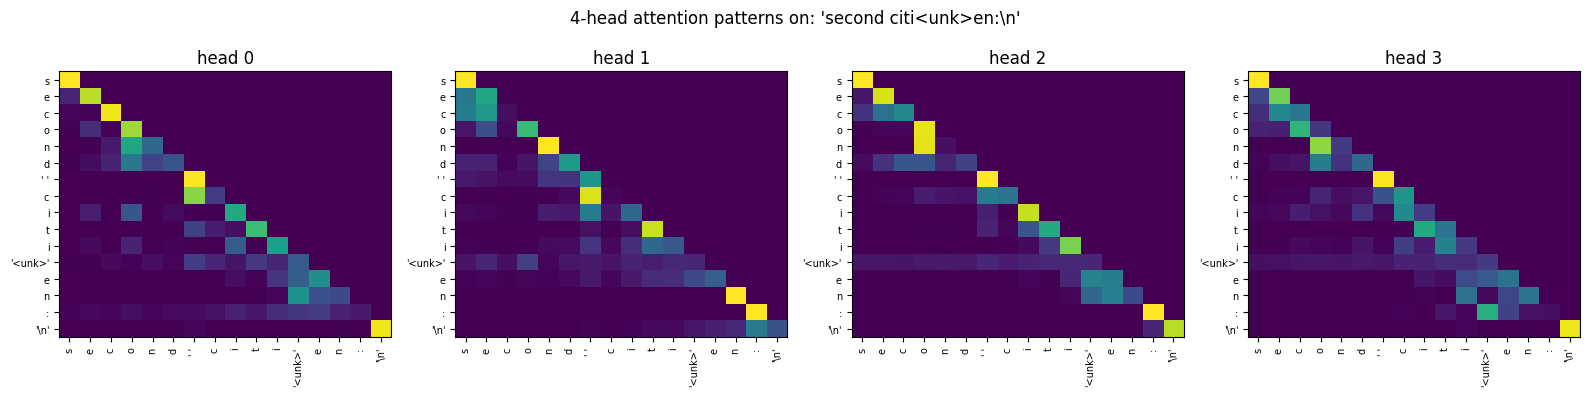

In [7]:
start = 1000
seq = data[start : start + BLOCK_SIZE].to(device)
m4.eval()
with torch.no_grad():
    x = m4.token_embed(seq.unsqueeze(0)) + m4.pos_embed(torch.arange(BLOCK_SIZE, device=device))
    _, all_weights = m4.attn(x, return_weights=True)   # (1, H, T, T)

labels = [repr(itos[i]) if itos[i] in (' ', '\n', '<unk>') else itos[i] for i in seq.tolist()]

H = all_weights.shape[1]
fig, axes = plt.subplots(1, H, figsize=(4*H, 4))
for h in range(H):
    ax = axes[h]
    ax.imshow(all_weights[0, h].cpu(), cmap='viridis', aspect='auto')
    ax.set_title(f'head {h}')
    ax.set_xticks(range(BLOCK_SIZE)); ax.set_xticklabels(labels, fontsize=7, rotation=90)
    ax.set_yticks(range(BLOCK_SIZE)); ax.set_yticklabels(labels, fontsize=7)
plt.suptitle(f'4-head attention patterns on: {repr(decode(seq.tolist()))}')
plt.tight_layout(); plt.show()


## Cell 6 — The hardware collapse: we must go back to 1 head

The Wozformer hardware spec is **1 head, 1 layer**. Why? Because each additional head means:

- More Q/K/V matrices in EEPROM (8 KB total budget).
- More 6502 cycles per token (we have ~150 ms per token at 1 MHz).
- More activation buffers in SRAM.

We've now seen what we're giving up: a (small but real) accuracy improvement from parallel specialized attention patterns. The `MultiHeadAttention` *code* stays in the codebase as a generalization — we just instantiate it with `num_heads=1` for the hardware build, making it equivalent to a single `Head` (plus the output projection).

### The single-head model going forward

From here on, every notebook uses `num_heads=1`. That's `m1` from this notebook. Treat its loss (~2.30-ish, depending on seed) as the new baseline to beat. Notebook 05's additions (layernorm + residuals + MLP) should push us further down.


## Post-mortem

### What multi-head taught us

It's the same parameter budget, organized as `H` specialists instead of one generalist. At large scale (GPT-2 had 12 heads × 64 dim each = 768), this matters enormously. At our scale (4 × 2 = 8), the win is small but **the mechanism is identical** — and you now know what every "multi-head attention" diagram in every paper is doing.

### What we gave up by collapsing to 1

The ability to attend to *multiple different things at once*. A single head has to pick one attention pattern per position; multi-head lets you pick H. For our 32-token vocab and 16-token context, the model just doesn't have enough degrees of freedom for specialization to matter much. For GPT-4, it matters profoundly.

### Onwards

Notebook 05: LayerNorm + residual connections + feed-forward MLP. These three additions are what unlock **depth** — the ability to stack blocks. We won't stack many (hardware limits us to 1 layer), but we'll see exactly what each piece adds and why it matters for training stability.
